# Seção 4. Estudo de Caso: Catálogo DES DR2

**Banco de dados:** `dados/processed/course_database.db`  
**Schema:**
- `objects(id, ra, dec, mag_auto_g, mag_auto_r, mag_auto_i, mag_auto_z, mag_auto_y, color_gr, color_ri, extended_class, redshift, region)`
- `observations(obs_id, object_id, band, num_obs)`

**Pipeline:**
1. Explorar o schema do banco
2. Selecionar galáxias com cobertura multi-banda
3. Gerar diagrama cor-magnitude (CMD)
4. Rankear e exportar catálogo de alvos

---

## 1. Importações e conexão

In [115]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext

DB = '../dados/processed/course_database.db'

---
## 2. Exploração do schema

In [116]:
with sqlite3.connect(DB) as conn:
    cur = conn.cursor()

    # Tabelas disponíveis
    cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name != 'sqlite_sequence'")
    tabelas = [r[0] for r in cur.fetchall()]
    print('Tabelas:', tabelas)

    # Contagem de linhas
    for t in tabelas:
        cur.execute(f'SELECT COUNT(*) FROM {t}')
        print(f'  {t}: {cur.fetchone()[0]:,} linhas')

Tabelas: ['objects', 'observations']
  objects: 150,000 linhas
  observations: 675,127 linhas


In [117]:
# Primeiras linhas de cada tabela
with sqlite3.connect(DB) as conn:
    print('=== objects ===')
    display(pd.read_sql_query('SELECT * FROM objects LIMIT 3', conn))

    print('\n=== observations ===')
    display(pd.read_sql_query('SELECT * FROM observations LIMIT 3', conn))

=== objects ===


,id,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,mag_auto_z,mag_auto_y,color_gr,color_ri,extended_class,redshift,region
0,1218358698,29.454858,-24.620595,23.202372,22.831989,22.61470,22.783230,22.029501,0.370382,0.217289,2.0,2.176361,A
1,1218358702,29.553099,-24.613220,22.597330,21.080133,20.55460,20.243847,20.193960,1.517197,0.525534,3.0,1.015113,A
2,1218358731,29.391050,-24.623151,24.231155,23.946810,23.79668,23.381283,22.251492,0.284346,0.150129,1.0,1.275867,A



=== observations ===


,obs_id,object_id,band,num_obs
0,1,1239290424,g,4
1,2,1239290424,r,5
2,3,1239290424,i,5


In [118]:
# Distribuição de extended_class (tipo de objeto)
with sqlite3.connect(DB) as conn:
    df_cls = pd.read_sql_query("""
        SELECT extended_class, COUNT(*) AS n
        FROM objects GROUP BY extended_class ORDER BY n DESC
    """, conn)

print('Valores de extended_class:')
print('  3.0 = galáxia, 0.0 = estrela, outros = incertos')
print(df_cls.to_string(index=False))

Valores de extended_class:
  3.0 = galáxia, 0.0 = estrela, outros = incertos
 extended_class      n
            3.0 120405
            0.0  15689
            2.0  11042
            1.0   2859
           -9.0      5


In [119]:
# Bandas disponíveis em observations
with sqlite3.connect(DB) as conn:
    df_bands = pd.read_sql_query("""
        SELECT band, COUNT(*) AS n FROM observations GROUP BY band
    """, conn)
print(df_bands.to_string(index=False))

band      n
   g 150000
   i 150000
   r 150000
   y  75127
   z 150000


---
## 3. Etapa 1: Seleção de galáxias

Filtros:
- `extended_class = 3` -> galáxias
- `mag_auto_i < 23.0` -> limite de brilho
- cobertura em pelo menos 3 bandas distintas (via JOIN com `observations`)

In [120]:
SQL_SELECAO = """
    WITH cobertura AS (
        SELECT object_id
        FROM   observations
        GROUP  BY object_id
        HAVING COUNT(DISTINCT band) >= 3
    )
    SELECT o.id,
           o.ra,
           o.dec,
           o.mag_auto_i,
           o.color_gr
    FROM   objects o
    JOIN   cobertura c ON o.id = c.object_id
    WHERE  o.mag_auto_i    <  23.0
      AND  o.extended_class =  3
"""

with sqlite3.connect(DB) as conn:
    df = pd.read_sql_query(SQL_SELECAO, conn)

print(f'Galáxias selecionadas: {len(df):,}')
df.describe()

Galáxias selecionadas: 103,475


,id,ra,dec,mag_auto_i,color_gr
count,1.034750e+05,103475.000000,103475.000000,103475.000000,103475.000000
mean,1.233814e+09,30.887150,-24.271410,21.631625,0.903190
std,6.549569e+06,0.809749,0.949998,1.115163,0.588817
min,1.218359e+09,29.357768,-27.920069,13.737369,-2.358873
25%,1.229595e+09,30.222400,-24.572608,21.064246,0.604949
50%,1.234142e+09,30.942417,-24.100621,21.904228,0.845778
75%,1.239797e+09,31.555614,-23.678735,22.475977,1.138839
max,1.250284e+09,32.644638,-22.978959,22.999914,77.403738


---
## 4. Diagnóstico com EXPLAIN QUERY PLAN

In [121]:
with sqlite3.connect(DB) as conn:
    cur = conn.cursor()
    cur.execute('EXPLAIN QUERY PLAN ' + SQL_SELECAO)
    for row in cur.fetchall():
        print(row)

(2, 0, 0, 'CO-ROUTINE cobertura')
(9, 2, 223, 'SCAN observations USING INDEX idx_observations_object_id')
(41, 2, 0, 'USE TEMP B-TREE FOR count(DISTINCT)')
(46, 0, 82, 'SCAN c')
(49, 0, 45, 'SEARCH o USING INTEGER PRIMARY KEY (rowid=?)')


---
## 5. Etapa 2: Diagrama Cor-Magnitude (CMD)

- **Eixo X:** cor $g-r$ (temperatura: galáxias azuis vs vermelhas)
- **Eixo Y:** magnitude $i$ (brilho. eixo invertido: menor = mais brilhante)

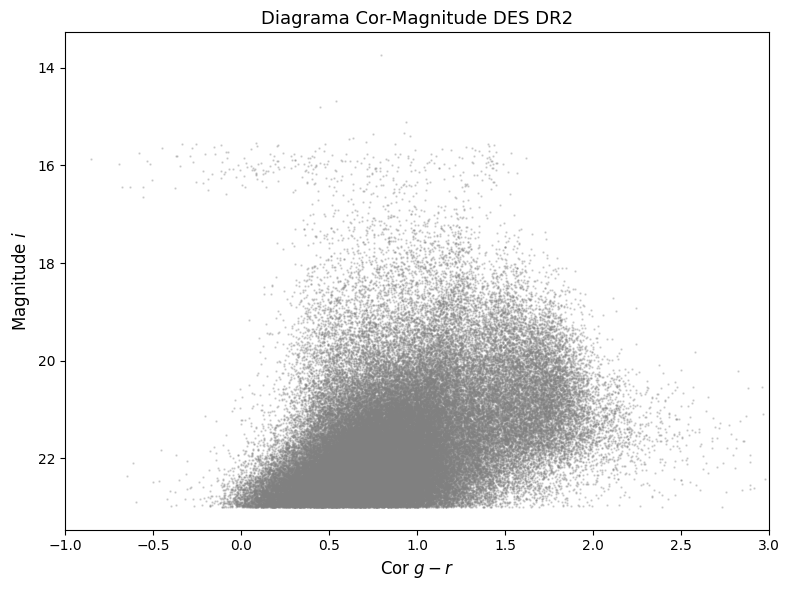

103,475 galáxias plotadas


In [122]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df['color_gr'],
    df['mag_auto_i'],
    s=0.5, alpha=0.3,
    c='gray',
    rasterized=True
)

ax.invert_yaxis()
ax.set_xlabel('Cor $g - r$', fontsize=12)
ax.set_ylabel('Magnitude $i$', fontsize=12)
ax.set_title('Diagrama Cor-Magnitude DES DR2', fontsize=13)
ax.set_xlim(-1, 3)

plt.tight_layout()
plt.savefig('../dados/cmd_des_dr2.png', dpi=150)
plt.show()
print(f'{len(df):,} galáxias plotadas')

Cada ponto representa uma galáxia. O eixo horizontal mostra a cor da galáxia: valores menores indicam galáxias mais azuis (com formação de estrelas ativa), valores maiores indicam galáxias mais vermelhas (mais antigas e passivas). 

O eixo vertical mostra o brilho: quanto mais alto no gráfico, mais brilhante a galáxia. O corte visível na magnitude 23 é o nosso filtro da query. A forma de leque, mais larga para baixo, reflete que galáxias fracas são muito mais numerosas do que galáxias brilhantes, o que é esperado em qualquer levantamento astronômico profundo.

In [123]:
counts = h[0]
print(counts.max())

88.0


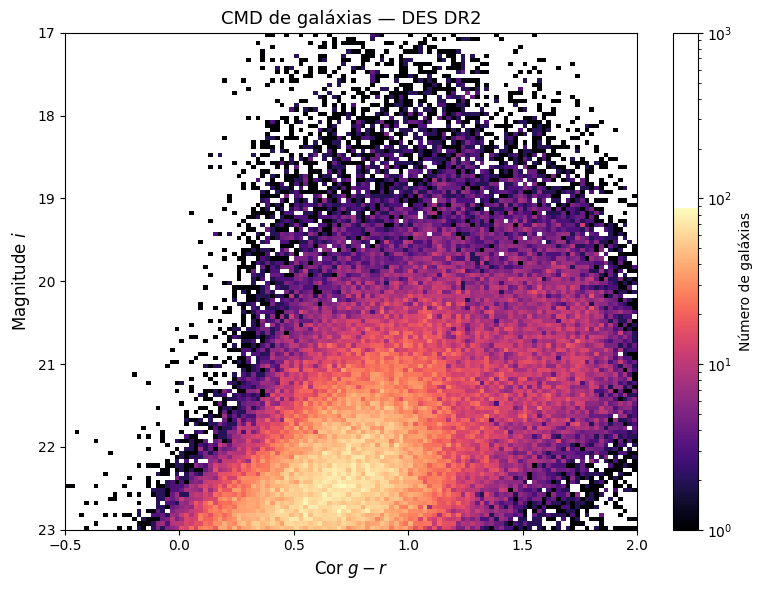

In [124]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext

fig, ax = plt.subplots(figsize=(8, 6))

h = ax.hist2d(
    df['color_gr'],
    df['mag_auto_i'],
    bins=(120, 120),
    range=[[-0.5, 2.0], [17, 23]],
    cmap='magma',
    norm=LogNorm(vmin=1)
)

cbar = plt.colorbar(h[3], ax=ax)

cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatterMathtext(base=10)
cbar.set_ticks([1, 10, 100, 1000])
cbar.update_ticks()

cbar.set_label('Número de galáxias')

ax.set_ylim(23, 17)

ax.set_xlabel(r'Cor $g-r$', fontsize=12)
ax.set_ylabel(r'Magnitude $i$', fontsize=12)
ax.set_title('CMD de galáxias — DES DR2', fontsize=13)

plt.tight_layout()
plt.savefig('../dados/cmd_des_dr2_densidade.png', dpi=150)
plt.show()

O mesmo diagrama anterior, agora com as galáxias agrupadas em células coloridas pela quantidade de objetos, usando uma escala logarítmica de cor. Branco/laranja indica regiões de altíssima densidade (milhares de galáxias por célula), roxo escuro indica regiões esparsas, e células completamente vazias aparecem em branco.

O pico de densidade aparece em torno de cor g−r ~ 0.7–1.0 e magnitude i ~ 22–23: a maioria das galáxias selecionadas é moderadamente vermelha
e relativamente fraca, consistente com galáxias típicas a distâncias intermediárias. A queda suave em direção a magnitudes brilhantes (topo
do gráfico) reflete que galáxias próximas e brilhantes são muito mais raras do que galáxias distantes e fracas, quanto mais fundo olhamos
no universo, mais objetos encontramos.

---
## 6. Etapa 3: Ranking e exportação do catálogo

In [125]:
# Ranking global por brilho (menor magnitude = mais brilhante)
df['rank'] = df['mag_auto_i'].rank(method='min')

top500 = df[df['rank'] <= 500].copy().sort_values('mag_auto_i')

print(f'Galáxias selecionadas: {len(top500)}')
print(f'Magnitude mínima: {top500["mag_auto_i"].min():.3f}')
print(f'Magnitude máxima: {top500["mag_auto_i"].max():.3f}')
top500[['id', 'ra', 'dec', 'mag_auto_i', 'color_gr']].head(10)

Galáxias selecionadas: 500
Magnitude mínima: 13.737
Magnitude máxima: 17.322


,id,ra,dec,mag_auto_i,color_gr
26091,1229598551,30.355766,-23.392050,13.737369,0.794811
51148,1234139126,30.647843,-24.464484,14.678789,0.539177
63021,1235395258,31.333327,-23.699113,14.808008,0.446384
94585,1241026320,31.649168,-23.870777,15.104483,0.936069
71752,1239265036,31.615740,-24.872794,15.327357,0.927597
94022,1241022036,31.847286,-23.809412,15.358417,0.748822
82049,1239823975,31.621882,-24.296926,15.404852,0.958132
96380,1241561262,31.865568,-23.131026,15.436431,0.637834
6332,1221128382,29.368190,-24.569370,15.449188,0.613772
95685,1241554723,31.799710,-23.067868,15.520882,0.710002


In [126]:
# Exportar catálogo de alvos
colunas = ['id', 'ra', 'dec', 'mag_auto_i', 'color_gr']
top500[colunas].to_csv('../dados/alvos_des_dr2.csv', index=False)
print('Exportado: dados/alvos_des_dr2.csv')

Exportado: dados/alvos_des_dr2.csv


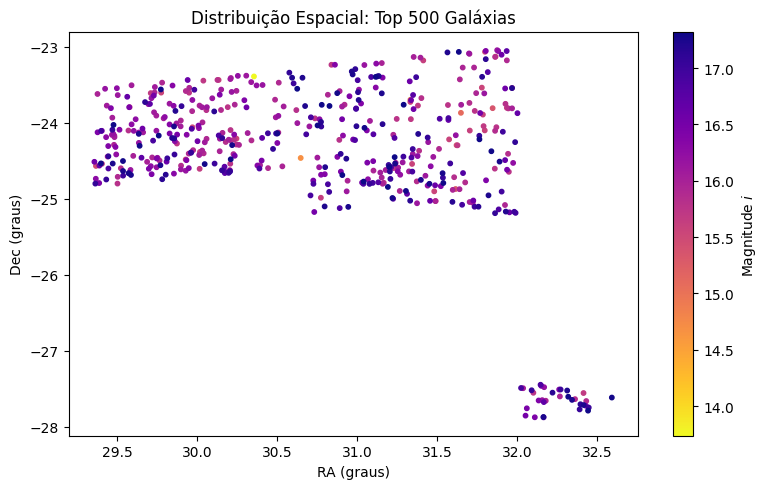

In [127]:
# Distribuição espacial dos alvos
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    top500['ra'], top500['dec'],
    s=10, c=top500['mag_auto_i'],
    cmap='plasma_r'
)
plt.colorbar(sc, ax=ax, label='Magnitude $i$')
ax.set_xlabel('RA (graus)')
ax.set_ylabel('Dec (graus)')
ax.set_title('Distribuição Espacial: Top 500 Galáxias')
plt.tight_layout()
plt.savefig('../dados/mapa_alvos.png', dpi=150)
plt.show()

Cada ponto mostra a posição no céu de uma das 500 galáxias mais brilhantes selecionadas, em coordenadas de Right Ascension (RA) e Declinação (Dec). A cor indica o brilho: tons amarelos e laranja são as galáxias mais brilhantes, tons escuros as mais fracas dentro do top 500. 

Os dois grupos separados no gráfico refletem a geometria do levantamento DES. O survey não cobre o céu de forma contínua, mas em campos específicos. O grupo menor isolado (RA ~ 32°, Dec ~ −28°) é um campo separado do DES DR2.